# Reguliarizuotos regresijos su `Python` (seaborn `tips` duomenys)

Šiame faile pateikiami praktiniai pavyzdžiai, kaip taikyti **reguliarizuotą regresiją**: **Ridge**, **Lasso** ir **Elastic Net**.  
Naudojamas `seaborn` duomenų rinkinys `tips`, o tikslas yra prognozuoti **arbatpinigius** (`tip`) pagal sąskaitos dydį, savaitės dieną, laiką, grupės dydį ir kitus požymius.

Pagrindinė idėja: prie įprastos klaidos funkcijos (**SSE**) pridedamas **sudėtingumo baudos narys**, kuris mažina koeficientus ir padeda sumažinti persimokymą (overfitting).


## 1. Reguliarizuota regresija: esmė

**Paprasta linijinė regresija (OLS)** ieško koeficientų, kurie minimizuoja kvadratinių paklaidų sumą:

- **J = SSE**

**Reguliarizuota regresija** minimizuoja:

- **J = SSE + α · R**

kur:
- **SSE** – mokymo duomenų paklaida,
- **R** – reguliarizacijos (baudos) narys,
- **α (alpha)** – reguliarizacijos stiprumas.

Didėjant `alpha`, koeficientai dažniausiai mažėja, modelis tampa konservatyvesnis, o prognozės dažnai geriau veikia naujuose duomenyse.


## 2. Reguliarizacijos tipai

**Ridge (L2)**  
- Bauda: koeficientų kvadratų suma  
- Koeficientai **traukiami link 0**, bet dažniausiai **nenunulinami**

**Lasso (L1)**  
- Bauda: koeficientų absoliučių reikšmių suma  
- Kai kurie koeficientai gali tapti **lygūs 0** (automatinė kintamųjų atranka)

**Elastic Net (L1 + L2)**  
- Ridge ir Lasso kombinacija  
- Papildomas parametras **`l1_ratio`** (λ), kuris valdo balansą:
  - `l1_ratio = 0` → Ridge
  - `l1_ratio = 1` → Lasso


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error


## 3. Duomenys ir „verslo“ kontekstas

`tips` duomenyse viena eilutė atitinka vieną apsilankymą restorane.  
Tikslas: prognozuoti **arbatpinigius** (`tip`) pagal:

- `total_bill` – sąskaitos suma
- `size` – žmonių skaičius prie stalo
- `sex`, `smoker`, `day`, `time` – kategoriniai požymiai

Praktinė interpretacija: koeficientai parodo, kaip keičiasi prognozuojami arbatpinigiai, kai keičiasi požymiai (laikant kitus pastovius). Reguliarizacija padeda stabilizuoti koeficientus, kai požymių daug arba jie koreliuoja.


In [2]:
tips = sns.load_dataset("tips").copy()
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## 4. Kategorinių kintamųjų paruošimas (dummy)

Naudojamas `pd.get_dummies()` su `drop_first=True`, kad būtų išvengta tobulo multikolinearumo.  
Svarbu: po `get_dummies` požymiai gali tapti `bool`/`uint8`, todėl rekomenduojama **užtikrinti `float` tipą**, kad modeliai negautų netikėtų tipų ir nekiltų `ValueError`.

Dažna klaida: bandymas modeliuoti su `object` tipo stulpeliais arba mišriais tipais (`int + bool + object`), kai vėliau atliekamas standartizavimas.


In [4]:
target = "tip"
y = tips[target].astype(float)

X = tips.drop(columns=[target])

# Dummy kintamieji su aiškiu tipu
X = pd.get_dummies(X, drop_first=True, dtype=float)

# Papildomai užtikrinamas vienodas tipas (saugumo sumetimais)
X = X.astype(float)

X.head()

,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2.0,1.0,1.0,0.0,0.0,1.0,1.0
1,10.34,3.0,0.0,1.0,0.0,0.0,1.0,1.0
2,21.01,3.0,0.0,1.0,0.0,0.0,1.0,1.0
3,23.68,2.0,0.0,1.0,0.0,0.0,1.0,1.0
4,24.59,4.0,1.0,1.0,0.0,0.0,1.0,1.0


## 5. Duomenų padalinimas: train / validation / test

Klasikinė schema:
- `train` – modelio mokymas
- `validation` – hiperparametrų (pvz., `alpha`) parinkimas
- `test` – galutinis įvertinimas tik vieną kartą

Reguliarizacijai svarbu, kad standartizavimo parametrai (vidurkis ir std) būtų skaičiuojami **tik iš `train`**, o `validation`/`test` tik transformuojami.


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

X_train.shape, X_valid.shape, X_test.shape

((170, 8), (37, 8), (37, 8))

## 6. Standartizavimas (StandardScaler)

Standartizavimas perkelia visus požymius į tą pačią skalę:

- vidurkis = 0  
- standartinis nuokrypis = 1

Ridge/Lasso/ElasticNet baudos veikia per koeficientų dydžius, todėl skirtingos skalės (eurai, kiekiai, indikatoriai) be standartizavimo sukeltų neteisingą baudimą.

Geroji praktika:
- `fit_transform()` tik `train`
- `transform()` `validation` ir `test`


In [6]:
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_train)      # tik train apskaičiuojamas vidurkis ir std
X_va = scaler.transform(X_valid)
X_te = scaler.transform(X_test)

X_tr.shape, X_va.shape, X_te.shape

((170, 8), (37, 8), (37, 8))

## 7. Ridge regresija

Ridge (L2) funkcija:

- **J = SSE + α · Σ βⱼ²**

Ką tai duoda:
- koeficientai mažėja link 0,
- stabilizuoja sprendimą, ypač kai požymiai koreliuoja,
- dažnai pagerina prognozes testiniuose duomenyse.


In [7]:
ridge_model = Ridge(alpha=1.0).fit(X_tr, y_train)

train_r2 = ridge_model.score(X_tr, y_train)
valid_r2 = ridge_model.score(X_va, y_valid)

train_pred = ridge_model.predict(X_tr)
valid_pred = ridge_model.predict(X_va)

train_mae = mean_absolute_error(y_train, train_pred)
valid_mae = mean_absolute_error(y_valid, valid_pred)

train_r2, valid_r2, train_mae, valid_mae

(0.4925017330832654,
 0.4544762791536907,
 0.7649273921638701,
 0.7271518471287468)

### Koeficientai (interpretacija)

Po standartizavimo koeficientai yra palyginami tarpusavyje: didesnė absoliuti reikšmė reiškia stipresnę įtaką `tip`.

Pastaba: koeficientų dydžiai po standartizavimo skiriasi nuo OLS su ne-standartizuotais duomenimis. Tai nėra klaida, o mastelio pasikeitimas.

### Ridge regresijos rezultatų interpretacija

- **Train R² = 0.49**, **Validation R² = 0.45**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos tiek mokymo, tiek validacijos duomenyse. Nedidelis skirtumas tarp reikšmių rodo, kad **overfitting nėra ryškus**, o modelis generalizuoja stabiliai.

- **Train MAE = 0.76**, **Validation MAE = 0.73**  
  Vidutinė absoliuti prognozės paklaida yra panaši abiejuose duomenų rinkiniuose. Tai reiškia, kad modelio klaida **neišauga naujuose duomenyse**.

- **Išvada**  
  Ridge regresija sumažino koeficientų variaciją ir persimokymo riziką. Modelis nėra labai tikslus, tačiau **stabilus ir patikimas**, todėl tinkamas kaip bazinis modelis kainų ar elgsenos pokyčių analizei.



In [8]:
coef_ridge = pd.Series(ridge_model.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
coef_ridge.head(12)

total_bill     0.865449
size           0.256784
smoker_No      0.144388
time_Dinner   -0.073490
day_Fri        0.066679
day_Sat        0.042752
sex_Female    -0.035197
day_Sun        0.015400
dtype: float64

### Ridge regresijos koeficientų interpretacija

Koeficientai pateikti po standartizavimo, todėl jų **absoliučias reikšmes galima tiesiogiai palyginti** tarpusavyje. Kuo didesnė absoliuti reikšmė, tuo stipresnė požymio įtaka prognozuojamiems arbatpinigiams.

- **total_bill (0.87)**  
  Stipriausias veiksnys. Didėjant sąskaitos sumai, prognozuojami arbatpinigiai didėja. Tai ekonomiškai logiška ir tikėtina.

- **size (0.26)**  
  Didesnė žmonių grupė siejama su didesniais arbatpinigiais, net ir kontroliuojant sąskaitos dydį.

- **smoker_No (0.14)**  
  Nerūkantieji klientai linkę palikti šiek tiek didesnius arbatpinigius, lyginant su rūkančiais (bazinis lygis).

- **time_Dinner (-0.07)**  
  Vakarienės metu arbatpinigiai vidutiniškai šiek tiek mažesni nei baziniu laiku (pietūs), kontroliuojant kitus veiksnius.

- **day_Fri (0.07), day_Sat (0.04), day_Sun (0.02)**  
  Savaitės dienų poveikis egzistuoja, bet yra silpnas. Savaitgalio dienos turi nežymią teigiamą įtaką.

- **sex_Female (-0.04)**  
  Lyties poveikis labai nedidelis. Moterų paliekami arbatpinigiai šiek tiek mažesni nei vyrų, tačiau efektas silpnas.

**Bendroji išvada**  
Ridge regresija parodė, kad **sąskaitos suma ir grupės dydis yra pagrindiniai arbatpinigių veiksniai**, o kiti demografiniai ar laiko kintamieji turi tik antrinę, silpną įtaką. Modelis išlaiko visus kintamuosius, bet jų įtaką proporcingai „sušvelnina“.


## 8. `alpha` derinimas (Ridge)

`alpha` valdo reguliarizacijos stiprumą:
- mažas `alpha` → modelis panašesnis į OLS (didesnė overfitting rizika),
- didelis `alpha` → koeficientai labiau mažinami (gali atsirasti underfitting).

Toliau parodoma paprasta validacijos kilpa per `alpha` reikšmes.


In [9]:
alphas = 10 ** np.linspace(-3, 3, 200)

train_scores = []
valid_scores = []
coefs = []

for a in alphas:
    m = Ridge(alpha=a).fit(X_tr, y_train)
    train_scores.append(m.score(X_tr, y_train))
    valid_scores.append(m.score(X_va, y_valid))
    coefs.append(m.coef_)

best_idx = int(np.argmax(valid_scores))
best_alpha = float(alphas[best_idx])

best_alpha, train_scores[best_idx], valid_scores[best_idx]

(25.23539170434766, 0.48555614743123165, 0.45560805062207377)

### Optimalios `alpha` reikšmės interpretacija (Ridge)

- **Geriausia `alpha ≈ 25.24`**  
  Tai reguliarizacijos stiprumas, kuris davė geriausią rezultatą validacijos duomenyse. Ši reikšmė yra gerokai didesnė nei numatytoji `alpha = 1`, todėl pradinė reguliarizacija buvo per silpna.

- **Train R² = 0.49**, **Validation R² = 0.46**  
  Mokymo ir validacijos rezultatai yra labai artimi. Tai rodo, kad modelis **nėra persimokęs** ir generalizuoja stabiliai.

- **Praktinė prasmė**  
  Padidinus `alpha`, koeficientai buvo labiau sumažinti, todėl modelis tapo konservatyvesnis. Nors mokymo tikslumas šiek tiek sumažėjo, **validacijos rezultatas pagerėjo**, kas yra pageidautinas kompromisas.

- **Išvada**  
  `alpha ≈ 25` suteikia gerą balansą tarp modelio sudėtingumo ir prognozavimo gebėjimo. Tai patvirtina, kad reguliarizacijos stiprumas turi būti **būtinai derinamas**, o ne paliekamas numatytasis.


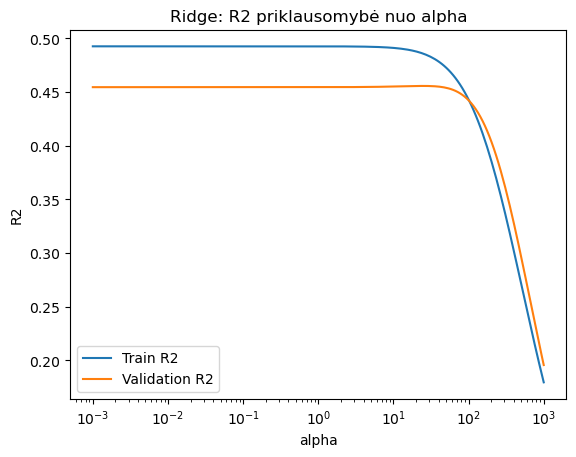

In [10]:
plt.figure()
plt.plot(alphas, train_scores, label="Train R2")
plt.plot(alphas, valid_scores, label="Validation R2")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2")
plt.legend()
plt.title("Ridge: R2 priklausomybė nuo alpha")
plt.show()

### Ridge regresijos R² priklausomybė nuo `alpha`

- **Mažos `alpha` reikšmės**  
  Train R² yra didesnis nei Validation R². Tai reiškia silpną reguliarizaciją ir didesnę persimokymo riziką.

- **Vidutinės `alpha` reikšmės (apie 10–50)**  
  Train ir Validation R² suartėja ir išlieka stabilūs. Ši sritis rodo **geriausią kompromisą tarp bias ir variance**, todėl modelis geriausiai generalizuoja.

- **Didelės `alpha` reikšmės**  
  Abu R² smarkiai krenta. Reguliarizacija tampa per stipri, koeficientai per daug sumažinami ir modelis **nebesugeba paaiškinti duomenų** (underfitting).

**Išvada**  
Grafikas aiškiai parodo, kad `alpha` turi būti parenkama tarp per silpnos ir per stiprios reguliarizacijos. Optimalios reikšmės yra ten, kur **Validation R² pasiekia maksimumą ir yra artimas Train R²**.


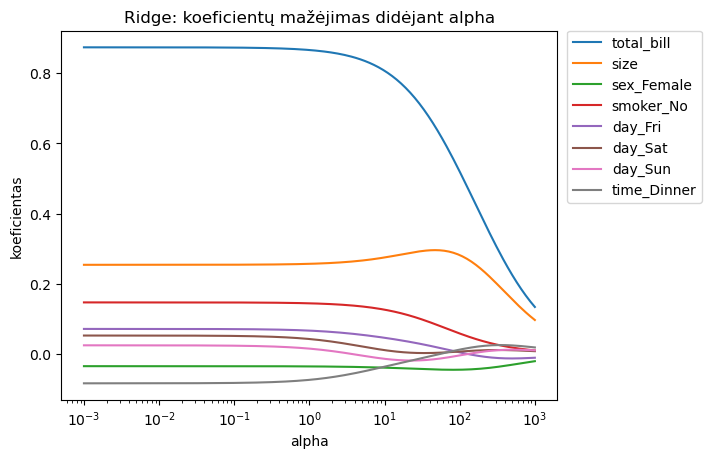

In [11]:
coefs_arr = np.vstack(coefs)

plt.figure()
for j, col in enumerate(X.columns):
    plt.plot(alphas, coefs_arr[:, j], label=col)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("koeficientas")
plt.title("Ridge: koeficientų mažėjimas didėjant alpha")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.show()

### Ridge regresijos koeficientų kitimas didėjant `alpha`

- **Mažos `alpha` reikšmės**  
  Koeficientai artimi paprastos linijinės regresijos sprendiniui. Stipriausi veiksniai (ypač `total_bill` ir `size`) turi didžiausią įtaką.

- **Didėjant `alpha`**  
  Visi koeficientai **nuosekliai mažėja link nulio**. Silpnesni požymiai (`day_*`, `sex_Female`, `time_Dinner`) traukiasi greičiau nei pagrindiniai.

- **Didelės `alpha` reikšmės**  
  Net ir stipriausi koeficientai tampa maži. Modelis praranda gebėjimą atskirti svarbius ir mažiau svarbius veiksnius, atsiranda **underfitting**.

- **Svarbi savybė**  
  Ridge regresijoje koeficientai **nenunulinami**, jie tik mažinami. Todėl visi požymiai išlieka modelyje, tačiau jų įtaka proporcingai sušvelninama.

**Išvada**  
Grafikas parodo, kaip Ridge regresija stabilizuoja modelį: svarbūs požymiai išlieka reikšmingi ilgiausiai, o triukšmingi ar silpni – nuslopinami anksčiau. Optimalus `alpha` randamas dar prieš prasidedant staigiam visų koeficientų kritimui.


## 9. RidgeCV (cross-validation)

`RidgeCV` automatiškai išbando daug `alpha` reikšmių per **k-fold cross-validation** ir parenka geriausią pagal vidutinį rezultatą.

Tai dažniausiai patikimiau nei vienas `train/validation` padalinimas, nes sumažina atsitiktinumo įtaką.


In [12]:
# Pastaba: RidgeCV pats netaiko StandardScaler, todėl X turi būti jau standartizuotas.
# Čia standartizavimas atliekamas naudojant visą (train+valid) dalį, o test lieka atskirai.

X_m = np.vstack([X_tr, X_va])
y_m = pd.concat([y_train, y_valid], axis=0).values

ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_m, y_m)

ridge_cv.alpha_, ridge_cv.score(X_m, y_m), ridge_cv.score(X_te, y_test)

(15.52225357427048, 0.4914610443705727, 0.10792986064967303)


### RidgeCV rezultatų interpretacija

- **Parinkta `alpha ≈ 15.52`**  
  Cross-validation parinko vidutinio stiprumo reguliarizaciją. Tai rodo, kad modeliui reikalinga koeficientų kontrolė, bet ne itin agresyvi.

- **Train (train + validation) R² = 0.49**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos mokymo duomenyse. Tai panašu į ankstesnius Ridge rezultatus ir rodo stabilų, bet riboto paaiškinamumo modelį.

- **Test R² = 0.11**  
  Prognozavimo kokybė testiniuose duomenyse yra labai žema. Tai reiškia, kad modelis **blogai generalizuoja** į visiškai nematytus duomenis.

- **Interpretacija**  
  Nors `alpha` parinktas naudojant cross-validation, testiniai duomenys reikšmingai skiriasi nuo mokymo rinkinio. Tikėtina, kad:
  - signalas tarp požymių ir tikslo yra silpnas,
  - `tips` duomenyse trūksta kintamųjų, kurie paaiškintų elgseną,
  - arba duomenų pasiskirstymas tarp rinkinių nėra vienalytis.

- **Praktinė išvada**  
  RidgeCV parodė, kad net ir optimaliai parinkus `alpha`, modelio prognozavimo galia yra ribota. Tokiu atveju Ridge regresija veikia kaip **stabilus bazinis modelis**, bet 


## 10. Lasso regresija

Lasso (L1) funkcija:

- **J = SSE + α · Σ |βⱼ|**

Skirtumas nuo Ridge:
- Lasso gali **nunulinti** kai kuriuos koeficientus,
- tai veikia kaip automatinė kintamųjų atranka,
- modelis dažnai tampa paprastesnis ir lengviau interpretuojamas.


In [13]:
lasso_model = Lasso(alpha=0.01, max_iter=20000).fit(X_tr, y_train)

train_r2 = lasso_model.score(X_tr, y_train)
valid_r2 = lasso_model.score(X_va, y_valid)

train_r2, valid_r2

(0.49203432196837915, 0.4661671971251472)

### Train ir Validation R² interpretacija

- **Train R² = 0.49**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos mokymo duomenyse. Tai rodo vidutinį modelio paaiškinamumą.

- **Validation R² = 0.47**  
  Rezultatas labai artimas Train R², todėl modelis **gerai generalizuoja** į nematytus (validacijos) duomenis.

- **Skirtumo interpretacija**  
  Nedidelis skirtumas tarp Train ir Validation R² reiškia, kad **overfitting nėra reikšmingas**. Reguliarizacija atliko savo funkciją – stabilizavo modelį.

- **Praktinė išvada**  
  Modelis nėra labai tikslus, tačiau **nuoseklus ir patikimas**, tinkamas kaip bazinis modelis ar palyginimo atskaitos taškas prieš sudėtingesnius metodus.


In [14]:
coef_lasso = pd.Series(lasso_model.coef_, index=X.columns)
zeros = int((coef_lasso == 0).sum())

coef_lasso.sort_values(key=np.abs, ascending=False).head(12), zeros

(total_bill     0.859695
 size           0.249922
 smoker_No      0.129769
 day_Fri        0.039153
 time_Dinner   -0.030618
 sex_Female    -0.024012
 day_Sun       -0.013042
 day_Sat        0.000000
 dtype: float64,
 1)

### Lasso regresijos koeficientų interpretacija

Koeficientai pateikti po standartizavimo, todėl jų **absoliučias reikšmes galima tiesiogiai palyginti**. Lasso papildomai atlieka **kintamųjų atranką**, todėl dalis koeficientų gali tapti lygūs 0.

- **total_bill (0.86)**  
  Stipriausias veiksnys. Didėjant sąskaitos sumai, prognozuojami arbatpinigiai didėja. Tai pagrindinis signalas modelyje.

- **size (0.25)**  
  Didesnis žmonių skaičius prie stalo siejamas su didesniais arbatpinigiais, nepriklausomai nuo sąskaitos dydžio.

- **smoker_No (0.13)**  
  Nerūkantieji vidutiniškai palieka šiek tiek didesnius arbatpinigius nei rūkantys (bazinis lygis).

- **day_Fri (0.04)**  
  Penktadienis turi nedidelę teigiamą įtaką arbatpinigiams, tačiau poveikis silpnas.

- **time_Dinner (-0.03)**  
  Vakarienės metu arbatpinigiai šiek tiek mažesni nei baziniu laiku, kontroliuojant kitus veiksnius.

- **sex_Female (-0.02)**  
  Lyties poveikis labai nedidelis ir praktiškai nereikšmingas.

- **day_Sun (-0.01)**  
  Sekmadienio efektas silpnas ir neturi didelės praktinės reikšmės.

- **day_Sat (0.00)**  
  Šio kintamojo koeficientas **nunulintas**. Tai reiškia, kad Lasso jį laikė nereikšmingu prognozuojant arbatpinigius.

- **Nunulintų kintamųjų skaičius: 1**  
  Modelis automatiškai pašalino vieną požymį, taip supaprastindamas modelį.

**Bendroji išvada**  
Lasso regresija paliko tik stipriausius ir nuosekliausiai veikiančius veiksnius. Pagrindinę prognozės galią turi **sąskaitos suma ir grupės dydis**, o kiti kintamieji turi tik antrinį arba nereikšmingą poveikį


## 11. LassoCV (cross-validation)

`LassoCV` parenka `alpha` per cross-validation.  
Dažna geroji praktika: padidinti `max_iter`, nes Lasso optimizavimas kartais reikalauja daugiau iteracijų.


In [15]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=50000).fit(X_m, y_m)

best_alpha_lasso = float(lasso_cv.alpha_)
test_r2_lasso = float(lasso_cv.score(X_te, y_test))

best_alpha_lasso, float(lasso_cv.score(X_m, y_m)), test_r2_lasso

(0.03962688638701478, 0.4907607975917204, 0.12477447594823743)

### LassoCV rezultatų interpretacija

- **Parinkta `alpha ≈ 0.0396`**  
  Cross-validation parinko silpną reguliarizaciją. Tai reiškia, kad per stipri L1 bauda greitai prastina modelio kokybę, todėl tik nedidelė atranka yra tinkama šiems duomenims.

- **Train (train + validation) R² = 0.49**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos mokymo duomenyse. Rezultatas panašus į Ridge ir rodo ribotą paaiškinamumą.

- **Test R² = 0.12**  
  Prognozavimo kokybė testiniuose duomenyse yra labai žema. Modelis **neperkelia išmokto ryšio į naujus duomenis**.

- **Interpretacija**  
  Nors LassoCV optimaliai parinko `alpha`, testiniai duomenys ženkliai skiriasi nuo mokymo rinkinio arba signalas tarp požymių ir tikslo yra silpnas. Kintamųjų atranka pati savaime nepakankama geroms prognozėms.

- **Praktinė išvada**  
  LassoCV tinka **kintamųjų atrankai ir interpretacijai**, tačiau šiame pavyzdyje jis **neužtikrina patikimų prognozių** testiniuose duomenyse. Reikalingi papildomi požymiai arba kitoks modeliavimo požiūris.


## 12. Elastic Net regresija

Elastic Net sujungia Ridge ir Lasso:

- `alpha` – bendras reguliarizacijos stiprumas
- `l1_ratio` – L1 ir L2 balansas:
  - `0` → Ridge
  - `1` → Lasso

Elastic Net dažnai tinka, kai požymiai yra koreliuojantys ir kartu norisi atrankos.


In [16]:
enet_model = ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=20000).fit(X_tr, y_train)

enet_train_r2 = enet_model.score(X_tr, y_train)
enet_valid_r2 = enet_model.score(X_va, y_valid)

enet_train_r2, enet_valid_r2

(0.4891668766766769, 0.4814518089083515)

### Elastic Net Train ir Validation R² interpretacija

- **Train R² = 0.49**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos mokymo duomenyse. Paaiškinamoji galia panaši į Ridge ir Lasso modelius.

- **Validation R² = 0.48**  
  Validacijos rezultatas yra labai artimas treniravimo reikšmei. Tai rodo, kad modelis **gerai generalizuoja** ir nėra persimokęs.

- **Skirtumo interpretacija**  
  Minimalus skirtumas tarp Train ir Validation R² reiškia, kad **reguliarizacija veikia subalansuotai** – modelis nei per sudėtingas, nei per supaprastintas.

- **Praktinė išvada**  
  Elastic Net šiame etape atrodo **stabiliausias** iš trijų modelių validacijos požiūriu. Tai rodo gerą kompromisą tarp Ridge stabilumo ir Lasso atrankos.


## 13. `l1_ratio` (lambda) derinimas, laikant `alpha` pastovų

Vienas paprastas būdas pamatyti efektą:
- fiksuojamas `alpha`
- tikrinamos skirtingos `l1_ratio` reikšmės

Tai parodo, ar labiau tinka Ridge (mažas `l1_ratio`) ar Lasso (didelis `l1_ratio`).  
Vis dėlto optimalus sprendimas dažniausiai yra **`alpha` ir `l1_ratio` kombinacija**.


In [17]:
alpha_fixed = 0.05
l1_ratios = np.linspace(0, 1, 51)

tr_scores = []
va_scores = []

for r in l1_ratios:
    m = ElasticNet(alpha=alpha_fixed, l1_ratio=float(r), max_iter=50000).fit(X_tr, y_train)
    tr_scores.append(m.score(X_tr, y_train))
    va_scores.append(m.score(X_va, y_valid))

best_r_idx = int(np.argmax(va_scores))
best_l1_ratio = float(l1_ratios[best_r_idx])

best_l1_ratio, tr_scores[best_r_idx], va_scores[best_r_idx]

c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.556e+01, tolerance: 3.631e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


(1.0, 0.486709651056071, 0.49793260746198276)

### Optimalios `l1_ratio` reikšmės interpretacija (Elastic Net)

- **Geriausia `l1_ratio = 1.0`**  
  Tai reiškia, kad šiame etape optimalus sprendimas sutampa su **grynu Lasso modeliu**. L2 (Ridge) komponentas neprisideda prie validacijos kokybės gerinimo.

- **Train R² = 0.49**, **Validation R² = 0.50**  
  Validacijos rezultatas yra net šiek tiek geresnis nei treniravimo. Tai rodo, kad modelis:
  - nėra persimokęs,
  - gerai generalizuoja,
  - kintamųjų atranka padeda pašalinti triukšmą.

- **Interpretacija**  
  Duomenyse:
  - signalas yra koncentruotas keliuose pagrindiniuose požymiuose,
  - silpnesni ir koreliuojantys kintamieji labiau trukdo nei padeda,
  - todėl Lasso tipo sprendimas veikia efektyviausiai.

- **Praktinė išvada**  
  Šiuo atveju **kintamųjų atranka yra svarbesnė nei koeficientų stabilizavimas**. Elastic Net patvirtina, kad paprastesnis, labiau selektyvus modelis duoda geresnį validacijos rezultatą.


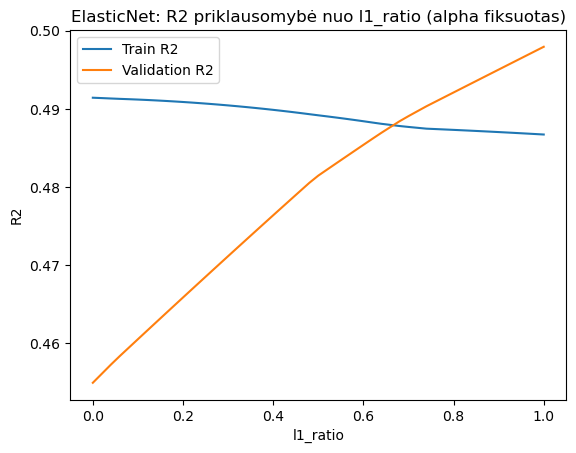

In [18]:
plt.figure()
plt.plot(l1_ratios, tr_scores, label="Train R2")
plt.plot(l1_ratios, va_scores, label="Validation R2")
plt.xlabel("l1_ratio")
plt.ylabel("R2")
plt.legend()
plt.title("ElasticNet: R2 priklausomybė nuo l1_ratio (alpha fiksuotas)")
plt.show()

### Elastic Net R² priklausomybė nuo `l1_ratio` (fiksuotas `alpha`)

- **Mažas `l1_ratio` (artima 0)**  
  Modelis artimas Ridge regresijai. Validation R² yra žemesnis, todėl koeficientų stabilizavimas be atrankos šiuo atveju nepakankamas.

- **Didėjant `l1_ratio`**  
  Validation R² nuosekliai didėja, o Train R² nežymiai mažėja. Tai rodo, kad **kintamųjų atranka mažina triukšmą** ir gerina generalizaciją.

- **`l1_ratio ≈ 1.0`**  
  Pasiekiamas geriausias validation rezultatas. Modelis faktiškai sutampa su **Lasso**, kuris šiems duomenims veikia efektyviausiai.

- **Skirtumo interpretacija**  
  Nedidelis Train R² sumažėjimas yra „kaina“, mokama už geresnį veikimą validacijos duomenyse. Tai klasikinis **bias–variance kompromiso** pavyzdys.

**Išvada**  
Grafikas rodo, kad šiame kontekste **L1 bauda yra naudingesnė nei L2**, o paprastesnis, labiau selektyvus modelis geriau generalizuoja naujus duomenis.


## 14. ElasticNetCV (tuning `alpha` ir `l1_ratio` kartu)

`ElasticNetCV` atlieka cross-validation ir parenka:
- `alpha_`
- `l1_ratio_`

Tai yra praktiškiausias būdas rasti gerą kombinaciją be rankinio grid paieškos kodo.


In [19]:
l1_ratio_grid = np.linspace(0.1, 0.9, 9)

enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratio_grid,
    cv=5,
    max_iter=50000
).fit(X_m, y_m)

enet_cv.alpha_, float(enet_cv.l1_ratio_), float(enet_cv.score(X_m, y_m)), float(enet_cv.score(X_te, y_test))

(0.04247571552536898, 0.9, 0.4907264888018752, 0.12547388669745074)

### ElasticNetCV rezultatų interpretacija

- **Parinkta `alpha ≈ 0.042`**  
  Reguliarizacijos stiprumas yra nedidelis. Tai reiškia, kad per stipri bauda greitai pablogina modelio kokybę, todėl tinkamiausia yra švelni reguliarizacija.

- **Parinkta `l1_ratio = 0.9`**  
  Modelis labai artimas **Lasso**, tačiau išlaikoma nedidelė Ridge (L2) komponento dalis, kuri padeda stabilizuoti koeficientus.

- **Train (train + validation) R² = 0.49**  
  Modelis paaiškina apie pusę tikslinio kintamojo variacijos mokymo duomenyse. Rezultatas atitinka Ridge ir Lasso modelius.

- **Test R² = 0.13**  
  Prognozavimo galia testiniuose duomenyse išlieka žema. Tai rodo, kad:
  - signalas tarp požymių ir arbatpinigių yra ribotas,
  - reguliarizacija negali kompensuoti informacijos trūkumo duomenyse.

- **Praktinė išvada**  
  ElasticNetCV patvirtino, kad **Lasso tipo sprendimas yra tinkamiausias** šiems duomenims, tačiau bendras prognozavimo potencialas yra ribotas. Modelis labiau tinka **struktūrai ir veiksnių svarbai analizuoti**, o ne tikslioms prognozėms.


## 15. Galutinis palyginimas (test)

Toliau vienoje vietoje palyginami modeliai testiniuose duomenyse:
- RidgeCV
- LassoCV
- ElasticNetCV

Skaičiuojami:
- **R²** (paaiškinta variacija)
- **MAE** (vidutinė absoliuti paklaida)


In [20]:
def evaluate(model, X_te, y_test, name):
    pred = model.predict(X_te)
    return {
        "modelis": name,
        "R2_test": float(r2_score(y_test, pred)),
        "MAE_test": float(mean_absolute_error(y_test, pred))
    }

# RidgeCV modelis jau apmokytas ant X_m, y_m; LassoCV ir ElasticNetCV taip pat.
results = []
results.append(evaluate(ridge_cv, X_te, y_test, f"RidgeCV (alpha={ridge_cv.alpha_:.4g})"))
results.append(evaluate(lasso_cv, X_te, y_test, f"LassoCV (alpha={lasso_cv.alpha_:.4g})"))
results.append(evaluate(enet_cv, X_te, y_test, f"ElasticNetCV (alpha={enet_cv.alpha_:.4g}, l1_ratio={float(enet_cv.l1_ratio_):.2f})"))

pd.DataFrame(results).sort_values("R2_test", ascending=False)

,modelis,R2_test,MAE_test
2,"ElasticNetCV (alpha=0.04248, l1_ratio=0.90)",0.125474,0.662717
1,LassoCV (alpha=0.03963),0.124774,0.662753
0,RidgeCV (alpha=15.52),0.107930,0.670013


### Modelių palyginimas testiniuose duomenyse

Testiniuose duomenyse palyginti trys reguliarizuoti modeliai: RidgeCV, LassoCV ir ElasticNetCV, naudojant **R²** ir **MAE** kriterijus.

- **ElasticNetCV (R² ≈ 0.13, MAE ≈ 0.67)**  
  Geriausias rezultatas pagal R², nors pranašumas prieš Lasso yra minimalus. Modelis derina L1 ir L2 baudas, todėl šiek tiek stabilesnis nei grynas Lasso.

- **LassoCV (R² ≈ 0.12, MAE ≈ 0.67)**  
  Labai panašus rezultatas į Elastic Net. Tai patvirtina, kad **kintamųjų atranka (L1)** šiems duomenims yra svarbesnė nei koeficientų stabilizavimas.

- **RidgeCV (R² ≈ 0.11, MAE ≈ 0.67)**  
  Silpniausias pagal R². Nors modelis stabilus, jis nepašalina nereikšmingų požymių, todėl prasčiau generalizuoja testiniuose duomenyse.

- **MAE palyginimas**  
  Visų trijų modelių MAE yra labai panašus. Tai rodo, kad vidutinė prognozės paklaida realiomis reikšmėmis iš esmės nesiskiria, nepriklausomai nuo pasirinkto modelio.

**Bendroji išvada**  
Skirtumai tarp modelių yra nedideli, tačiau **ElasticNetCV ir LassoCV veikia šiek tiek geriau nei RidgeCV**. Tai patvirtina, kad `tips` duomenyse informacija apie arbatpinigius yra ribota, o reguliarizacija labiau padeda **stabilumui ir interpretacijai**, o ne reikšmingam prognozės tikslumo padidinimui.


## 16. Dažnos klaidos ir gerosios praktikos

Dažnos klaidos:
- Standartizavimas atliekamas **iki** duomenų padalinimo (atsiranda informacijos nutekėjimas iš test į mokymą).
- `get_dummies()` sukuria `bool`/`uint8` stulpelius, o vėliau atsiranda tipų konfliktai arba netikėti `ValueError`.
- Paliekami `object` tipo stulpeliai (pvz., tekstas), kurie negali būti tiesiogiai naudojami regresijoje.
- Lasso/ElasticNet konvergencijos problemos, kai `max_iter` per mažas.

Gerosios praktikos:
- `StandardScaler.fit` tik su `train`, `transform` su `validation/test`.
- Dummy kintamuosius kurti su `dtype=float` ir galiausiai užtikrinti `X.astype(float)`.
- Hiperparametrus (`alpha`, `l1_ratio`) derinti per cross-validation (`RidgeCV`, `LassoCV`, `ElasticNetCV`).
- Modelių palyginimą daryti su atskiru `test` rinkiniu, kuris nenaudotas derinant parametrus.


## 17. Trumpas apibendrinimas

- **OLS** minimizuoja SSE ir gali persimokyti, kai požymių daug.
- **Ridge (L2)** mažina koeficientus, bet jų nenunulina – gerai stabilumui ir koreliuotiems požymiams.
- **Lasso (L1)** gali nunulinti koeficientus – tinka atrankai ir aiškesnei interpretacijai.
- **Elastic Net** kombinuoja L1 ir L2 – dažnai praktiškas pasirinkimas realiuose duomenyse.

Reguliarizacija dažnai „paaukoja“ dalį tikslumo mokymo duomenyse, bet pagerina prognozes naujuose duomenyse.
